<a href="https://colab.research.google.com/drive/1tnOvFNgXiLtktiSsltTr0s308LZSsEPJ">Abre este Jupyter en Google Colab</a>

# Linear Regression: Cost of a Security Incident

Objective: Predict the cost of a security incident based on the number of affected devices. The dataset is randomly generated.

### 0. Requirements

In [102]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install scikit-learn

### 1. Dataset generation

In [103]:
import numpy as np

In [104]:
X = 2 * np.random.rand(100, 1) # affected devices
y = 4 + 2 * X + np.random.randn(100, 1) # cost per device

print("Dataset size:", len(X))

Dataset size: 100


### 2. Dataset modification

In [105]:
import pandas as pd

In [106]:
data = {'affected_devices': X.flatten(), 'cost': y.flatten()}
df = pd.DataFrame(data)
# Affected devices scaling
df['affected_devices'] = df['affected_devices'] * 1000
df['affected_devices'] = df['affected_devices'].astype('int')
# Cost scaling
df['cost'] = df['cost'] * 10000
df['cost'] = df['cost'].astype('int')
df.head(10)

,affected_devices,cost
0,604,63251
1,1107,62454
2,948,66971
3,1980,58397
4,1638,62630
5,1368,64969
6,841,48840
7,362,36150
8,778,50278
9,1619,73675


### 3. Dataset visualization

In [107]:
import matplotlib.pyplot as plt
%matplotlib inline

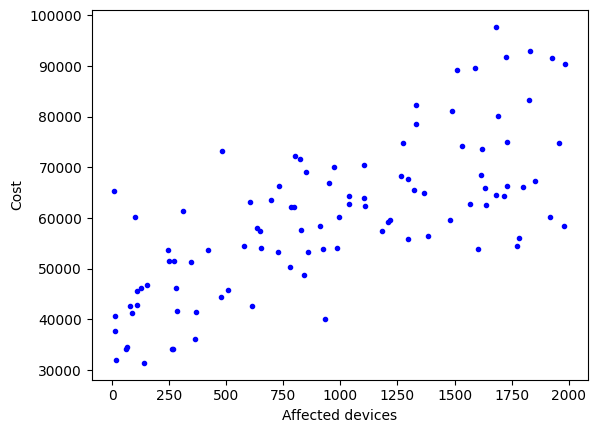

In [108]:
# Graphical dataset visualization
plt.plot(df['affected_devices'], df['cost'], "b.")
plt.xlabel("Affected devices")
plt.ylabel("Cost")
plt.show()

### 4. Model construction

In [109]:
from sklearn.linear_model import LinearRegression

In [110]:
# Model construction and hypothesis function fitting
lin_reg = LinearRegression()
lin_reg.fit(df['affected_devices'].values.reshape(-1, 1), df['cost'].values)

LinearRegression()

In [111]:
# Theta 0
lin_reg.intercept_

np.float64(42965.51448919953)

In [112]:
# Theta 1
lin_reg.coef_

array([17.78561521])

In [113]:
# Training dataset min and max value prediction
X_min_max = np.array([[df["affected_devices"].min()], [df["affected_devices"].max()]])
y_pred = lin_reg.predict(X_min_max)

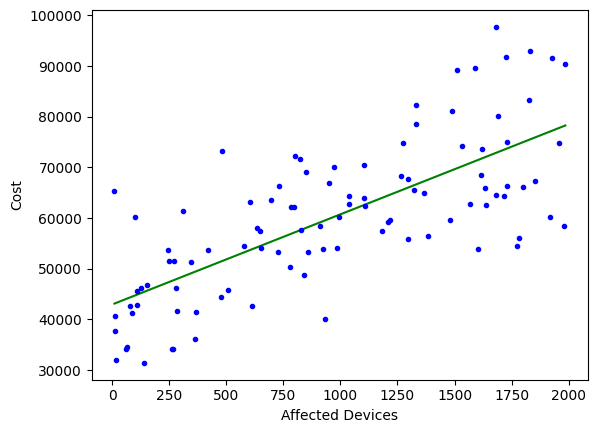

In [114]:
# Graphical representation of generated hypothesis function
plt.plot(X_min_max, y_pred, "g-")
plt.plot(df['affected_devices'], df['cost'], "b.")
plt.xlabel("Affected Devices")
plt.ylabel("Cost")
plt.show()

### 5. Prediction of new examples

In [ ]:
x_new = np.array([[1300]]) # 1300 affected devices

# Prediction of the incident cost
cost = lin_reg.predict(x_new)

print("The incident cost would be:", int(cost[0]), "€")

The incident cost would be: 66086 €


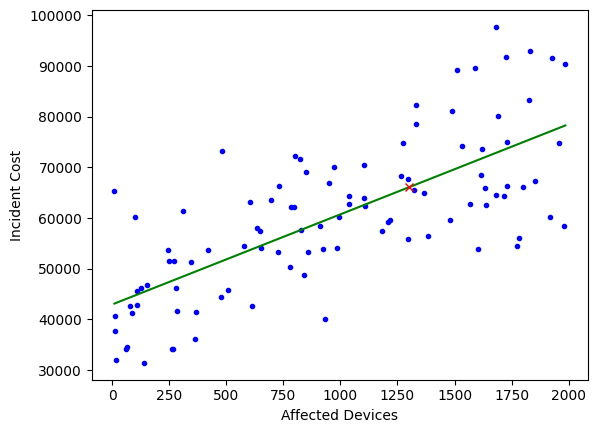

In [ ]:
plt.plot(df['affected_devices'], df['cost'], "b.")
plt.plot(X_min_max, y_pred, "g-")
plt.plot(x_new, cost, "rx")
plt.xlabel("Affected Devices")
plt.ylabel("Incident Cost")
plt.show()